In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split

In [20]:
df = pd.read_csv("airline_passengers.csv")

df['Month'] = pd.to_datetime(df['Month'])
df = df.sort_values('Month')


df.set_index('Month', inplace=True)


df['month'] = df.index.month

df.head()

,Passengers,month
Month,,
1949-01-01,112,1
1949-02-01,118,2
1949-03-01,132,3
1949-04-01,129,4
1949-05-01,121,5


In [21]:
df['lag1'] = df['Passengers'].shift(1)
df['lag2'] = df['Passengers'].shift(2)
df['lag3'] = df['Passengers'].shift(3)


df['rolling_mean_3'] = df['Passengers'].rolling(window=3).mean()
df['rolling_mean_6'] = df['Passengers'].rolling(window=6).mean()


df = df.dropna()

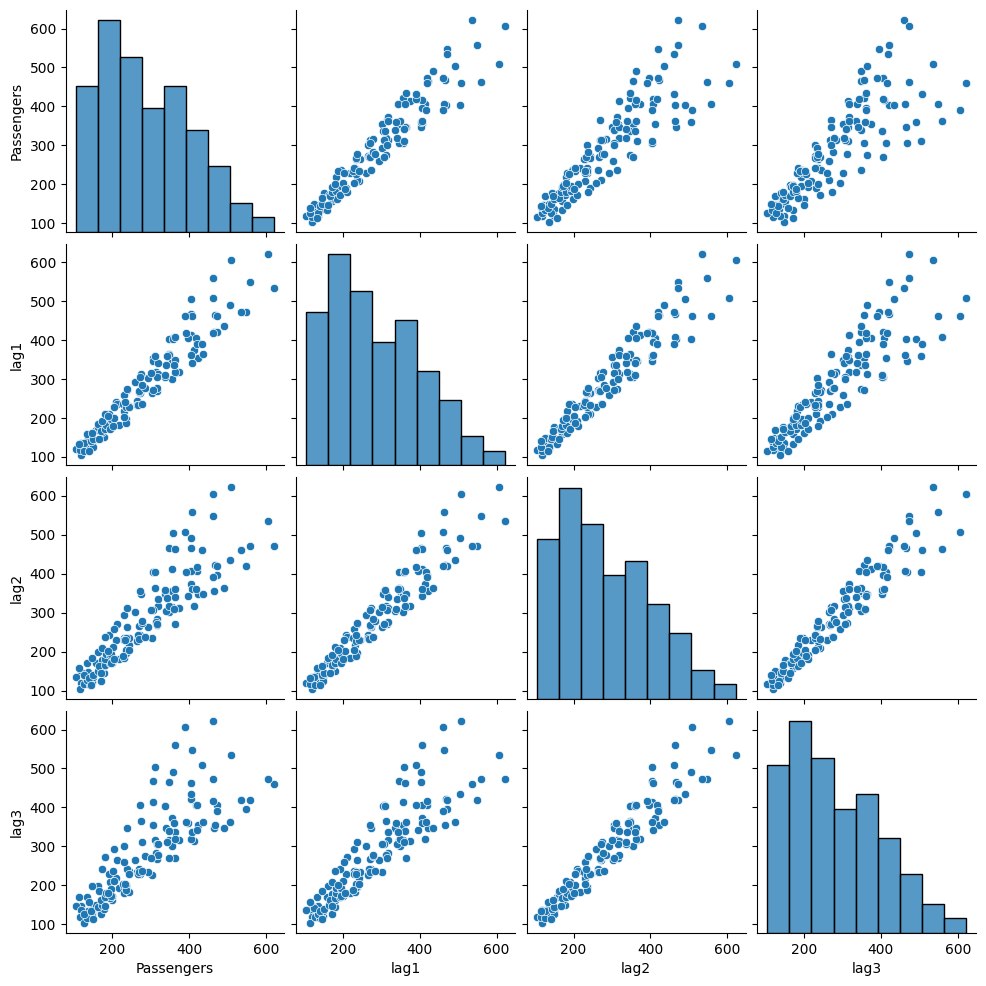

In [22]:
sns.pairplot(df[['Passengers','lag1','lag2','lag3']])
plt.show()

In [23]:
X = df[['month','lag1','lag2','lag3','rolling_mean_3','rolling_mean_6']]
y = df['Passengers']

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)


In [25]:
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [26]:
predictions = model.predict(X_test)

In [27]:
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, predictions)

print("MSE :", mse)
print("RMSE:", rmse)
print("MAE :", mae)


MSE : 3220.542453571428
RMSE: 56.7498233792091
MAE : 39.873214285714276


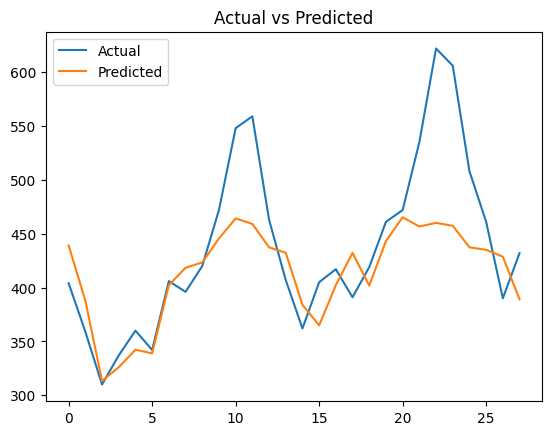

In [28]:
plt.figure()
plt.plot(y_test.values, label='Actual')
plt.plot(predictions, label='Predicted')
plt.legend()
plt.title("Actual vs Predicted")
plt.show()

In [29]:

future_preds = []


history = list(df['Passengers'].values)

current_month = df.index[-1].month

for i in range(12):
    current_month = (current_month % 12) + 1

    lag1 = history[-1]
    lag2 = history[-2]
    lag3 = history[-3]

    rolling_mean_3 = np.mean(history[-3:])
    rolling_mean_6 = np.mean(history[-6:])

    input_data = pd.DataFrame(
        [[current_month, lag1, lag2, lag3, rolling_mean_3, rolling_mean_6]],
        columns=['month','lag1','lag2','lag3','rolling_mean_3','rolling_mean_6']
    )

    pred = model.predict(input_data)[0]
    future_preds.append(float(round(pred, 2)))

    
    history.append(pred)

print("Next 12 Months Predictions:", future_preds)

Next 12 Months Predictions: [453.56, 463.47, 454.1, 452.39, 452.39, 452.11, 452.67, 449.76, 432.05, 425.16, 423.39, 421.54]


In [30]:
df['Predicted'] = model.predict(X)
df.to_csv("final_output.csv", index=True)

print("File saved as final_output.csv")

File saved as final_output.csv
